In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [2]:
depth_path = "/home/alexis/Documents/COMP558/COMP558-FinalProject/videos/DEPTH-20250109-142924.mp4"
frame_number = 1

In [3]:
bx, by, bw, bh = 275, 235, 115, 115
expand_x, expand_y = 50, 50

In [4]:
bx = int(bx - expand_x/2)
by = int(by - expand_y/2)

bw = bw + expand_x
bh = bh + expand_y

In [5]:
cap = cv.VideoCapture(depth_path)
cap.set(cv.CAP_PROP_POS_FRAMES, frame_number)

ret, frame = cap.read()
gray = cv.cvtColor(frame[by:by+bh, bx:bx+bw, ...], cv.COLOR_BGR2GRAY)

### 1. Normalize

In [6]:
depth_normalized = cv.normalize(gray, None, 0, 255, cv.NORM_MINMAX).astype(np.uint8)

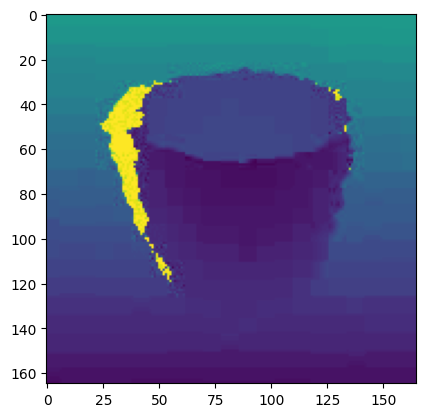

In [7]:
plt.imshow(depth_normalized)
plt.show()

### 2. Apply adaptive threshold

In [8]:
binary_treshold = cv.adaptiveThreshold(depth_normalized, 
                                       maxValue = 255, 
                                       adaptiveMethod = cv.ADAPTIVE_THRESH_GAUSSIAN_C, 
                                       thresholdType = cv.THRESH_BINARY_INV, 
                                       blockSize = 201, 
                                       C = 2)

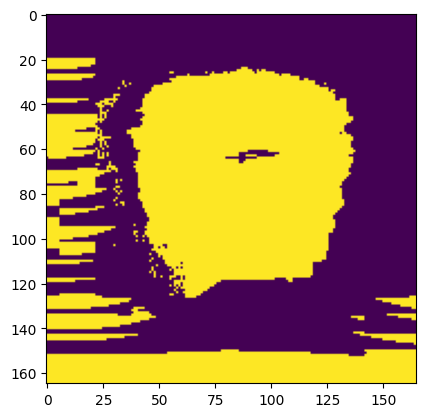

In [9]:
plt.imshow(binary_treshold)
plt.show()

### 3. Refine the binary mask

In [10]:
kernel = np.ones((3, 3), dtype = np.uint8)
cleaned_mask = cv.morphologyEx(binary_treshold, cv.MORPH_CLOSE, kernel, iterations = 2)
cleaned_mask = cv.morphologyEx(cleaned_mask, cv.MORPH_OPEN, kernel, iterations = 2)

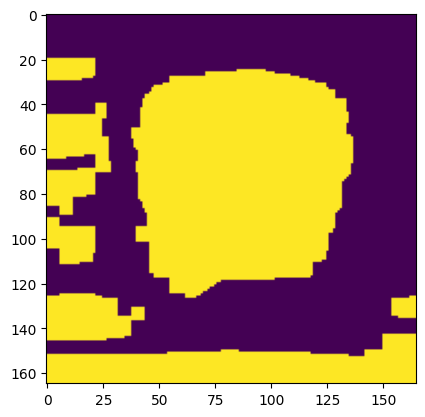

In [11]:
plt.imshow(cleaned_mask)
plt.show()

### 4. Generate markers for watershed

In [12]:
dist_transform = cv.distanceTransform(cleaned_mask, cv.DIST_L2, 5)
_, sure_fg = cv.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)

sure_fg = sure_fg.astype(np.uint8)
sure_bg = cv.dilate(cleaned_mask, kernel, iterations = 3)

unknown = cv.subtract(sure_bg, sure_fg)

_, markers = cv.connectedComponents(sure_fg)
markers += 1
markers[unknown == 255] = 0

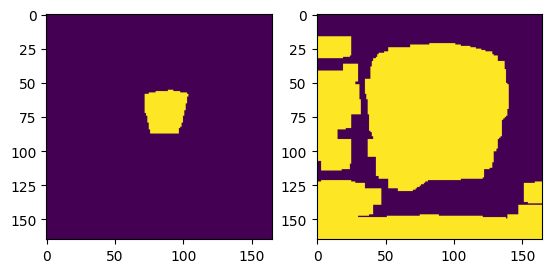

In [13]:
plt.subplot(1, 2, 1)
plt.imshow(sure_fg)

plt.subplot(1, 2, 2)
plt.imshow(sure_bg)

plt.show()

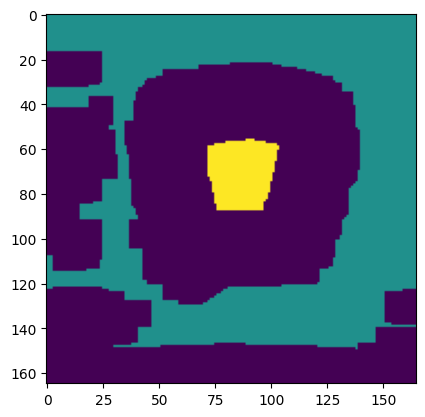

In [14]:
plt.imshow(markers)
plt.show()

### 5. Apply Watershed algorithm

In [15]:
depth_colored = cv.cvtColor(depth_normalized, cv.COLOR_GRAY2BGR)

markers = cv.watershed(depth_colored, markers)

depth_colored[markers == -1] = [255, 0, 0]

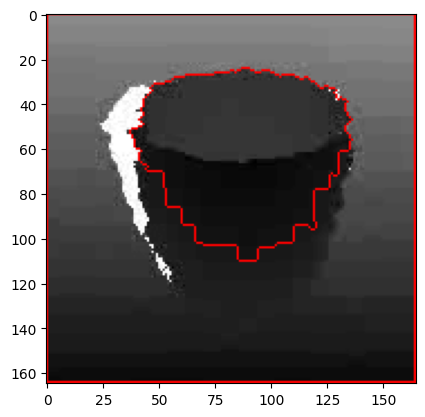

In [16]:
plt.imshow(depth_colored)

### 6. Extract Object

In [17]:
object_mask = (markers == 2).astype(np.uint8)

# segmented_object = cv.bitwise_and(rgb_image, rgb_image, mask = object_mask)

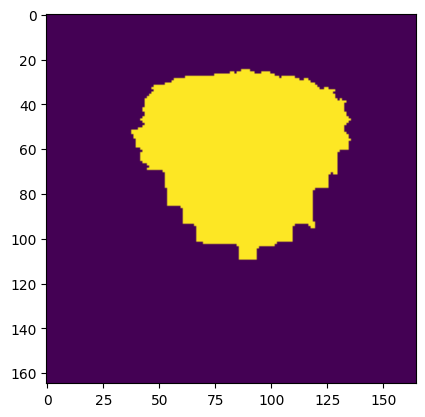

In [18]:
plt.imshow(object_mask)